Problem Statement:
Can machine learning predict tomorrow's stock price using only today's market data? In this task we use real Apple Inc. (AAPL) stock data fetched live from Yahoo Finance to find out.

Goal:
> To download and explore real-world stock market time series data
> To engineer features and predict next day's closing price
> To train and evaluate a Linear Regression model on financial data
> To visualize how closely predictions follow actual market prices
> To understand the challenges and limitations of stock price prediction


Installing and Importing Libraries:

In [1]:
# Run this once to install yfinance
%pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 2.1 MB/s eta 0:00:01
   ------------------------------- -------- 1.3/1.7 MB 2.3 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 2.2 MB/s eta 0:00:00

   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ---------------------------------------- 0/6 [peewee]
   ------------- -------------------------- 2/6 [websockets]
   ------------- -------------------------- 2/6 [websockets]
   ------------- --------------

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
print('All libraries loaded!')

All libraries loaded!


Downloading Stock Data:

In [3]:
# Download 2 years of Apple stock data
ticker = 'AAPL' # Change to 'TSLA' for Tesla, 'GOOGL' for Google
df = yf.download(ticker, start='2022-01-01', end='2024-01-01')
print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

(501, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939713,178.790267,173.735885,173.853197,104487900
2022-01-04,175.681366,178.848915,175.114335,178.545850,99310400
2022-01-05,171.008270,176.140865,170.734533,175.593390,94537600
2022-01-06,168.153580,171.379785,167.801630,168.837923,96904000
2022-01-07,168.319733,170.245678,167.205227,169.023632,86709100


Feature Engineering:

In [4]:
# Create target: next day's closing price
df['Next_Close'] = df['Close'].shift(-1)
# Drop the last row (it has no 'next day' value)
df = df.dropna()
# Select features (input) and target (output)
features = ['Open', 'High', 'Low', 'Volume', 'Close']
X = df[features]
y = df['Next_Close']
print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (500, 5)
Target shape: (500,)


Splitting Data into Train and Test Sets:

In [5]:
# 80% training data, 20% for testing
# shuffle=False is important for time-series data!
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, shuffle=False
)
print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 400
Testing samples: 100


Train the Model:

In [6]:
# Option A: Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)
# Option B: Random Forest (usually better - uncomment to use)
# model = RandomForestRegressor(n_estimators=100, random_state=42)
# model.fit(X_train, y_train)
print('Model trained!')

Model trained!


Evaluating the Model:

In [7]:
# Make predictions on the test set
y_pred = model.predict(X_test)
# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: ${mae:.2f}')
print(f'R2 Score: {r2:.4f}')  # 1.0 = perfect, 0 = useless

Mean Absolute Error: $1.72
R2 Score: 0.9345


Plotting Actual vs Predicted Prices:

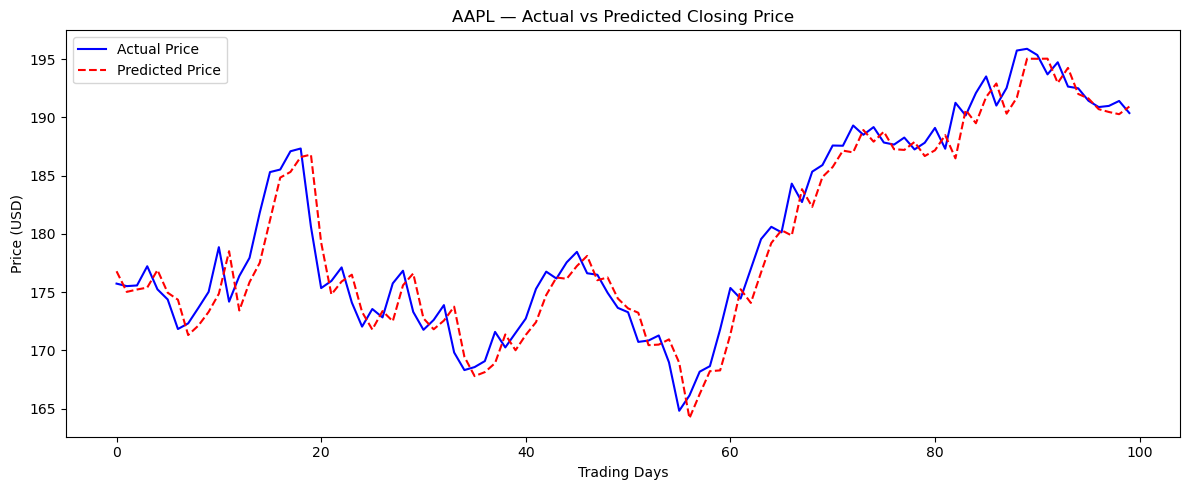

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(y_pred, label='Predicted Price', color='red', linewidth=1.5, linestyle='--')
plt.title(f'{ticker} — Actual vs Predicted Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

Explanation:

Task 2 — Stock Price Prediction

1.Objective:
 >Predict the next day's closing price of Apple (AAPL) stock using historical price and volume data from 2022 to 2024.

2.Dataset:
 >Source: Yahoo Finance via yfinance library
 >Stock: Apple Inc. (AAPL)
 >Period: January 2022 to January 2024
 >Samples: 501 trading days, 5 features (Open, High, Low, Close, Volume)


3.Steps Performed:
 >Downloaded real-time stock data using yfinance API
 >Created target variable — next day's closing price using shift(-1)
 >Split data chronologically — 400 training, 100 testing days
 >shuffle=False used to preserve time series order
 >Trained Linear Regression model
 >Evaluated using MAE and R² Score
 >Plotted Actual vs Predicted closing prices

4.Model Results:
 (MAE)Mean Absolute Error: $1.72 
 R² Score: 0.9345 

5.Results Interpretation:
 >MAE of $1.72 means predictions are off by $1.72 on average (strong performance for daily stock price predicton)
 >R² of 0.9345 appears strong but should be interpreted carefully —the model uses today's closing price to predict tomorrow's which are naturally very similar values
 >The Actual vs Predicted plot shows the red dashed line closely follows the blue actual price line — confirming strong model fit
 >Model struggles slightly during sharp reversals around trading day 55 — expected behavior as sudden market movements are hard to predict from price data alone

6.Key Findings:
 >Predicted prices closely follow actual prices showing the model captures short term price momentum
 >The model struggles during sudden price drops and sharp reversals as seen around trading day 55
 >Time series data must never be shuffled during splitting — shuffle=False preserves chronological order which is critical for honest evaluation

7.Key Takeaway
Linear Regression can capture next-day stock price trends with reasonable accuracy on historical data. However real-world stock prediction is far more complex — market sentiment, news, and external factors are not captured in price/volume data alone.